In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
spark = (
    SparkSession.builder
    .appName("CrimeDistrictRiskAnalysis")
    .master("spark://spark-master:7077")
    .getOrCreate()
)

print("Spark initialized.")


Spark initialized.


In [3]:
df = spark.read.parquet(
    "hdfs://namenode:9000/data/processed/chicago_crimes_clean.parquet"
)

print("Loaded records:", df.count())
df.printSchema()


Loaded records: 8422096
root
 |-- ID: string (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- crime_datetime: timestamp (nullable = true)
 |-- crime_year: integer (nullable = true)
 |-- crime_month: integer (nullable = true)
 |-- crime_day: integer (nullable = true)
 |-- crime_hour: integer (nullable = true)
 |-- crime_day_of_week: integer (nullable = true)
 |-- time_of_day: string (nullable = true)
 |-- season: string (nullable = true)
 |-- location_category: string (nullable = t

In [4]:
# ---------------------------------------------------------
# Create a binary indicator for nighttime crimes
# Nighttime is defined as:
# - crime_hour >= 22 (10 PM)
# - crime_hour < 6  (before 6 AM)
# ---------------------------------------------------------
df = df.withColumn(
    "is_night",
    (col("crime_hour") >= 22) | (col("crime_hour") < 6)
)

In [5]:
# ---------------------------------------------------------
# Aggregate statistics at the police district level
# ---------------------------------------------------------
district_stats = (
    df.groupBy("District")
      .agg(
          # Total number of crimes in each district
          count("*").alias("total_crimes"),

          # Number of nighttime crimes (sum of binary indicator)
          sum(col("is_night").cast("int")).alias("night_crimes"),

          # Arrest rate: average of arrest indicator
          avg(col("Arrest").cast("int")).alias("arrest_rate")
      )
      # Proportion of crimes occurring at night
      .withColumn(
          "night_crime_ratio",
          col("night_crimes") / col("total_crimes")
      )
)

In [6]:
# ---------------------------------------------------------
# Convert Spark DataFrame to Pandas for visualization
# (Safe here because there are only ~22 districts)
# ---------------------------------------------------------
district_stats_pd = district_stats.toPandas()
district_stats_pd.head()


,District,total_crimes,night_crimes,arrest_rate,night_crime_ratio
0,31.0,277,61,0.335740,0.220217
1,12.0,425005,117562,0.215026,0.276613
2,22.0,274988,70878,0.203253,0.257749
3,1.0,350841,60349,0.261497,0.172012
4,16.0,283106,79253,0.182101,0.279941


In [7]:
# ---------------------------------------------------------
# Prepare data for plotting
# ---------------------------------------------------------
df_plot = district_stats_pd.copy()

# Drop rows with missing district values
df_plot = df_plot.dropna(subset=["District"])

# Explicitly cast data types for plotting
df_plot["District"] = df_plot["District"].astype(int)
df_plot["night_crime_ratio"] = df_plot["night_crime_ratio"].astype(float)
df_plot["arrest_rate"] = df_plot["arrest_rate"].astype(float)

df_plot.head()

,District,total_crimes,night_crimes,arrest_rate,night_crime_ratio
0,31,277,61,0.335740,0.220217
1,12,425005,117562,0.215026,0.276613
2,22,274988,70878,0.203253,0.257749
3,1,350841,60349,0.261497,0.172012
4,16,283106,79253,0.182101,0.279941


In [8]:
# ---------------------------------------------------------
# Compute global averages for reference lines
# ---------------------------------------------------------
avg_night = df_plot["night_crime_ratio"].mean()
avg_arrest = df_plot["arrest_rate"].mean()

avg_night, avg_arrest

(0.26444541774825986, 0.2610876741122935)

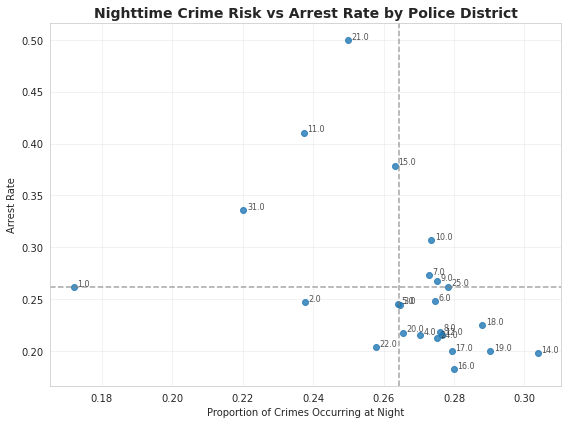

Saved: night_risk_vs_arrest.png


In [9]:
# ---------------------------------------------------------
# Scatter plot:
# Nighttime crime proportion vs. arrest rate by district
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

plt.scatter(
    df_plot["night_crime_ratio"],
    df_plot["arrest_rate"],
    alpha=0.8
)

# Add reference lines for global averages
plt.axvline(avg_night, linestyle="--", color="gray", alpha=0.7)
plt.axhline(avg_arrest, linestyle="--", color="gray", alpha=0.7)

# Annotate each point with district ID
for _, row in df_plot.iterrows():
    plt.text(
        row["night_crime_ratio"] + 0.001,
        row["arrest_rate"] + 0.001,
        str(row["District"]),
        fontsize=8,
        alpha=0.8
    )
    
plt.title(
    "Nighttime Crime Risk vs Arrest Rate by Police District",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Proportion of Crimes Occurring at Night")
plt.ylabel("Arrest Rate")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "/home/jovyan/notebooks/outputs/night_risk_vs_arrest.png",
    dpi=300
)
plt.show()
plt.close()

print("Saved: night_risk_vs_arrest.png")


In [10]:
spark.stop()